# Trade Execution

Runs execution strategies against the 5-minute `BINNED_DATA` bins and analyses the results (fill rate, implementation shortfall, cost).

All reusable logic lives in [`execution.py`](execution.py); this notebook is the driver. (`test_snowflake.ipynb` stays the data explorer.)

**Layers** (see `execution.py` docstrings for full detail):

| Function | What it does |
|---|---|
| `simulate_bin_fill` | scalar reference model for a single bin |
| `twap_schedule` | baseline strategy: split quantity evenly across the day's bins |
| `vwap_schedule` | baseline strategy: split quantity by each bin's share of the day's volume |
| `run_strategy` | run one order `(security, date, side, quantity)` → per-bin fills |
| `run_trade_list` | run many orders (the trade list) → per-bin fills with `order_id` |
| `summarise_fills` | collapse to one row per order with fill rate / IS / cost |


In [63]:
import polars as pl
from execution import (
    twap_schedule,
    vwap_schedule,
    build_liq_spread_curves,
    build_rolling_curves,
    vwap_static,
    liq_spr_static,
    vwap_adaptive,
    vwap_adaptive_v2,
    omniscient_vwap,
    omniscient_liq_spr,
    omniscient,
    run_strategy,
    run_trade_list,
    summarise_fills,
    decompose_is_stats,
)

pl.Config.set_tbl_cols(-1)
RAW = "data/raw"

trade_list = pl.read_csv(f"{RAW}/trade_list.csv")
trade_list.head()


security,date,trade_list,side,quantity
str,str,str,str,i64
"""IK2026M Comdty""","""2026-03-06""","""small_buys""","""buy""",333
"""IK2026M Comdty""","""2026-03-09""","""small_buys""","""buy""",334
"""IK2026M Comdty""","""2026-03-10""","""small_buys""","""buy""",333
"""IK2026M Comdty""","""2026-03-11""","""small_buys""","""buy""",339
"""IK2026M Comdty""","""2026-03-12""","""small_buys""","""buy""",343


## Load bins

For a quick demo we load bins for just a couple of instruments (one liquid, one illiquid). For a full back-test, read the whole table instead — it is ~13M rows / ~2.5 GB in memory:

```python
bins = pl.read_csv(f"{RAW}/binned_data.csv")
```

In [64]:
demo_secs = ["GC2025V Comdty", "PA2022Z Comdty"]  # liquid gold, illiquid palladium

bins = (
    pl.scan_csv(f"{RAW}/binned_data.csv")
    .filter(pl.col("security").is_in(demo_secs))
    .collect()
)
bins

qcode,publication_date,security,bin_start_time,gmt_offset_hours,open,high,low,close,twa_bid_size,twa_ask_size,bid_size_start,bid_size_end,ask_size_start,ask_size_end,volume,signed_volume,trade_count,vwap,twa_bid,twa_ask,bid_start,bid_end,ask_start,ask_end
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""GC""","""2025-08-21""","""GC2025V Comdty""","""12:30:00.000000000""",-4.0,3357.0,3357.2,3356.9,3357.1,3.72327,4.416947,7,2,4,1,5,3,5,3357.06,3357.106662,3357.428751,3357.4,3357.0,3357.8,3357.2
"""GC""","""2025-08-21""","""GC2025V Comdty""","""13:05:00.000000000""",-4.0,3358.0,3358.3,3358.0,3358.3,3.769527,4.040703,2,4,5,4,2,-1,2,3358.15,3358.166469,3358.434343,3357.5,3357.9,3357.7,3358.2
"""GC""","""2025-09-26""","""GC2025V Comdty""","""07:15:00.000000000""",-4.0,3743.7,3745.3,3743.3,3745.3,3.585983,3.639973,3,2,5,6,12,7,12,3743.933333,3744.485734,3744.780858,3743.4,3746.2,3743.7,3746.5
"""GC""","""2025-09-05""","""GC2025V Comdty""","""07:30:00.000000000""",-4.0,3576.6,3576.6,3575.6,3575.8,3.80029,3.624047,8,2,2,1,15,2,11,3576.033333,3575.999761,3576.24569,3576.3,3575.8,3576.6,3576.0
"""GC""","""2025-09-05""","""GC2025V Comdty""","""14:10:00.000000000""",-4.0,3621.0,3621.0,3619.2,3619.2,3.153997,3.67401,2,7,2,6,7,2,7,3620.071429,3621.03912,3621.265013,3622.2,3619.0,3622.4,3619.3
"""GC""","""2025-09-24""","""GC2025V Comdty""","""09:00:00.000000000""",-4.0,3768.5,3770.7,3767.8,3768.9,3.72978,2.987313,2,5,2,7,65,19,40,3769.393846,3768.949029,3769.242463,3768.9,3768.9,3769.2,3769.2
"""GC""","""2025-09-10""","""GC2025V Comdty""","""13:55:00.000000000""",-4.0,3657.7,3657.8,3657.6,3657.8,5.4855,5.988557,4,7,3,1,3,0,3,3657.7,3657.491375,3657.737614,3656.7,3657.8,3656.9,3658.1
"""GC""","""2025-08-29""","""GC2025V Comdty""","""15:30:00.000000000""",-4.0,3484.0,3485.4,3484.0,3485.3,5.78876,5.59683,4,10,1,5,19,16,15,3484.836842,3484.63353,3484.877418,3484.2,3485.0,3484.4,3485.3
"""GC""","""2025-09-19""","""GC2025V Comdty""","""04:00:00.000000000""",-4.0,3655.8,3657.1,3655.6,3657.1,3.547737,3.516967,6,2,5,3,23,13,6,3655.969565,3656.171726,3656.460603,3655.8,3656.9,3656.1,3657.1


## Evaluation metrics

Every strategy below is scored the same way: `summarise_fills` collapses the per-bin fills to **one row per order**. The three headline numbers (full column-by-column reference in [`docs/execution_metrics.md`](docs/execution_metrics.md)):

- **`fill_rate`** = `total_filled / order_quantity` — fraction of the order that actually got done. A strategy that allocates to zero-volume bins can't fill there, so illiquid names (e.g. `PA`) under-fill — the gap a smarter schedule should close.
- **`exec_slippage_bps`** — filled-only slippage vs the arrival price, signed so **positive = worse**.
- **`is_bps`** — implementation shortfall vs arrival price, including opportunity cost on the unfilled remainder marked at the day's terminal price. Captures both spread *and* intraday price drift, and — unlike the other two — it penalises a low `fill_rate`, so it's the right top-line score when comparing strategies.

**Plugging in a new strategy:** write a function `my_strategy(bins, quantity, **params) -> Sequence[float]` returning the per-bin requested quantities, and pass `strategy=my_strategy` to `run_strategy` / `run_trade_list`. Everything downstream (fill model, metrics) stays the same — only the per-bin allocation changes, which is what makes the strategies comparable.

## TWAP

**TWAP (Time-Weighted Average Price)** splits the order **evenly across every bin** in the day — `quantity / n_bins` each — regardless of how much volume a bin actually had. It's the naive baseline: it allocates to zero-volume / no-trade bins too, so that quantity never fills and is lost. The under-filling this causes on illiquid or short days is exactly what a smarter schedule should beat.

### Single order

Take one real order (one bucket for a security-day) and run it through TWAP. `run_strategy` takes the bins for that `(security, date)` plus the order's `side` and `quantity`, and returns one row per bin.

In [65]:
# pick one real order from the trade list (one row = one bucket for a security-day)
order = trade_list.filter(pl.col("security") == "GC2025V Comdty").row(0, named=True)
print(order)

day = bins.filter(
    (pl.col("security") == order["security"])
    & (pl.col("publication_date") == order["date"])
)

fills = run_strategy(day, side=order["side"], quantity=order["quantity"], strategy=twap_schedule)
fills.head()

{'security': 'GC2025V Comdty', 'date': '2025-07-31', 'trade_list': 'large_buys', 'side': 'buy', 'quantity': 761}


order_id,security,publication_date,qcode,side,order_quantity,bin_start_time,volume,open,vwap,twa_bid,twa_ask,spread,q_requested,q_filled,q_unfilled,participation_rate,slippage_factor,fill_price,notional,cost,filled,data_available
i32,str,str,str,str,f64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:00:00.000000000""",23,3323.0,3323.421739,3322.799493,3323.088507,0.289015,5.0,5.0,0.0,0.217391,0.231856,3323.488749,16617.443745,0.335049,true,true
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:05:00.000000000""",233,3323.1,3324.727468,3323.683917,3323.962368,0.27845,5.0,5.0,0.0,0.021459,0.141427,3324.766848,16623.834241,0.196902,true,true
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:10:00.000000000""",165,3323.7,3324.784848,3324.371042,3324.66078,0.289738,5.0,5.0,0.0,0.030303,0.149229,3324.828086,16624.140429,0.216187,true,true
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:15:00.000000000""",19,3323.6,3323.752632,3323.940178,3324.289575,0.349397,5.0,5.0,0.0,0.263158,0.245073,3323.838259,16619.191297,0.428139,true,true
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:20:00.000000000""",36,3325.4,3325.483333,3325.593179,3325.900623,0.307444,5.0,5.0,0.0,0.138889,0.205393,3325.54648,16627.732402,0.315735,true,true


In [66]:
summarise_fills(fills)

order_id,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps
i32,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,157,156,156,7973,761.0,754.0,2.5079e6,2.5079e6,47.546288,3323.0,3316.984615,0.990802,3326.125306,7.0,0.094569,9.405073,2314.372744,9.152048,0.188019,9.130542,-0.166512


### The whole trade list

The `TRADE_LIST` table has six rows per (security, date) — `small_buys`, `small_sells`, `medium_buys`, `medium_sells`, `large_buys`, `large_sells`. Pass `trade_list=` to run **one bucket at a time** (the usual back-test). Each order gets a unique `order_id` and is auto-tagged with its bucket.

Here TWAP runs the `medium_buys` bucket. Watch the illiquid `PA` rows under-fill (`fill_rate < 1`): TWAP keeps allocating to bins with no volume to fill against.

In [67]:
orders = trade_list.filter(pl.col("security").is_in(demo_secs))

# run a single bucket, e.g. medium_buys (one of the six)
all_fills = run_trade_list(bins, orders, trade_list="medium_buys", strategy=twap_schedule)
all_fills.shape

(16929, 24)

In [68]:
summary = summarise_fills(all_fills)
summary.sort("security", "side")

order_id,trade_list,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps
i32,str,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
65,"""medium_buys""","""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",76.0,157,156,76,7973,76.0,76.0,253133.835017,253130.591403,3.243614,3323.0,3316.984615,1.0,3330.708355,0.0,0.009532,23.196977,585.835017,23.196977,0.128436,23.068542,-0.0
107,"""medium_buys""","""GC2025V Comdty""","""2025-09-29""","""GC""","""buy""",50.0,157,124,43,965,50.0,43.0,163818.449926,163814.906208,3.543718,3812.3,3821.3,0.86,3809.731394,7.0,0.04456,-6.737682,-47.450074,-2.489315,0.18591,-5.980316,3.305091
106,"""medium_buys""","""GC2025V Comdty""","""2025-09-26""","""GC""","""buy""",52.0,157,145,48,2439,52.0,48.0,179814.302415,179810.517363,3.785052,3739.5,3763.743478,0.923077,3746.1313,4.0,0.01968,17.73312,415.276328,21.356019,0.19465,16.174384,4.986985
105,"""medium_buys""","""GC2025V Comdty""","""2025-09-25""","""GC""","""buy""",54.0,157,156,53,4274,54.0,53.0,198782.754549,198779.842381,2.912168,3738.3,3746.742857,0.981481,3750.61801,1.0,0.012401,32.950834,661.297406,32.75887,0.144261,32.196373,0.418236
104,"""medium_buys""","""GC2025V Comdty""","""2025-09-24""","""GC""","""buy""",55.0,157,156,54,4140,55.0,54.0,203624.20133,203620.737473,3.463858,3773.6,3730.85,0.981818,3770.818543,1.0,0.013043,-7.370831,-192.94867,-9.296581,0.166894,-7.40371,-2.059764
103,"""medium_buys""","""GC2025V Comdty""","""2025-09-23""","""GC""","""buy""",55.0,157,157,55,5643,55.0,55.0,207655.014742,207652.454765,2.559977,3757.3,3765.416667,1.0,3775.545723,0.0,0.009747,48.560729,1003.514742,48.560729,0.123879,48.43685,0.0
102,"""medium_buys""","""GC2025V Comdty""","""2025-09-22""","""GC""","""buy""",57.0,157,157,57,4080,57.0,57.0,212350.150044,212347.194862,2.955182,3718.3,3751.3125,1.0,3725.441229,0.0,0.013971,19.205629,407.050044,19.205629,0.139433,19.066196,0.0
101,"""medium_buys""","""GC2025V Comdty""","""2025-09-19""","""GC""","""buy""",59.0,157,153,55,3614,59.0,55.0,201123.875782,201120.518407,3.357376,3651.7,3687.06,0.932203,3656.797741,4.0,0.015219,13.959913,421.815782,19.578333,0.155831,12.857648,6.564855
100,"""medium_buys""","""GC2025V Comdty""","""2025-09-18""","""GC""","""buy""",61.0,157,155,59,4055,61.0,59.0,216366.583466,216363.528545,3.054921,3641.1,3650.098387,0.967213,3667.230228,2.0,0.01455,71.764654,1559.68024,70.221989,0.137543,69.274172,0.810275


## VWAP (historical volume)

**VWAP (Volume-Weighted Average Price)** splits the order across bins **in proportion to each bin's typical share of the day's volume** instead of evenly — heavier at the open/close, thin midday — and allocates **nothing** to bins that are normally dead, so it fills better than TWAP on illiquid names where naive TWAP wastes quantity on empty bins.

Crucially, a deployable VWAP **cannot know the volume profile of the day it is trading** — using that day's realised volume would be lookahead. So we weight by the **static historical curve**: the average volume of each 5-minute bin for that security across all days (`vwap_static`, built once by `build_liq_spread_curves`). Everything downstream (fill model, metrics) is identical; only the per-bin allocation changes.

> A realised-volume variant (`vwap_schedule`, weighting by the *actual* volume of the day being traded) also exists in `execution.py`, but it has perfect hindsight of the profile, so it is kept only as a reference and is not used here.

### Single order

The same order as the TWAP single-order example above, now through `vwap_static`. It needs the static curves, so we build them from the loaded `bins` first (here the two demo securities).

In [69]:
# static historical spread+liquidity curves for the loaded demo securities
# (used by vwap_static and liq_spr_static; no same-day lookahead)
demo_curves = build_liq_spread_curves(bins)

# single order, VWAP on the historical-average volume curve
vwap_fills = run_strategy(day, side=order["side"], quantity=order["quantity"],
                          strategy=vwap_static, strategy_params={"curves": demo_curves})
summarise_fills(vwap_fills)

order_id,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps
i32,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,157,156,156,7973,761.0,756.0,2.5144e6,2.5144e6,45.182048,3323.0,3316.984615,0.99343,3325.947736,5.0,0.09482,8.870707,2198.411331,8.693486,0.17867,8.633754,-0.118937


### The whole trade list

The same `medium_buys` bucket as the TWAP run above, now under `vwap_static`. Compare the `fill_rate` on the illiquid `PA` rows: by steering quantity toward bins that *historically* trade and away from normally-dead ones, VWAP recovers much of what naive TWAP wasted.

A full fill is **not** guaranteed, though — `vwap_static` only weights bins with historical volume, so it still under-fills when the order is larger than the day can absorb (each bin caps at `2 × volume`), on days the static profile misjudges, or in bins with volume but missing prices. (`liq_spr_static` and `omniscient` below push the fill rate and cost further.)

In [70]:
# run the same bucket through vwap_static (historical volume) and summarise
vwap_all_fills = run_trade_list(bins, orders, trade_list="medium_buys",
                                strategy=vwap_static, strategy_params={"curves": demo_curves})
vwap_summary = summarise_fills(vwap_all_fills)
vwap_summary.sort("security", "side")

order_id,trade_list,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps
i32,str,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
65,"""medium_buys""","""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",76.0,157,156,72,7973,76.0,75.0,249450.923495,249447.749088,3.174407,3323.0,3316.984615,0.986842,3326.012313,1.0,0.009407,9.065041,219.908111,8.707577,0.125695,8.820069,-0.238188
107,"""medium_buys""","""GC2025V Comdty""","""2025-09-29""","""GC""","""buy""",50.0,157,124,46,965,50.0,46.0,175596.042542,175592.36277,3.679772,3812.3,3821.3,0.92,3817.305273,4.0,0.047668,13.129273,266.242542,13.967555,0.193047,11.885884,1.888624
106,"""medium_buys""","""GC2025V Comdty""","""2025-09-26""","""GC""","""buy""",52.0,157,145,49,2439,52.0,49.0,184298.236235,184295.348472,2.887763,3739.5,3763.743478,0.942308,3761.188495,3.0,0.02009,57.998381,1135.466669,58.392559,0.148506,54.503814,3.740239
105,"""medium_buys""","""GC2025V Comdty""","""2025-09-25""","""GC""","""buy""",54.0,157,156,53,4274,54.0,54.0,201915.60823,201912.808608,2.799622,3738.3,3746.742857,1.0,3739.17793,0.0,0.012635,2.348474,47.40823,2.348474,0.138686,2.209789,0.0
104,"""medium_buys""","""GC2025V Comdty""","""2025-09-24""","""GC""","""buy""",55.0,157,156,54,4140,55.0,54.0,202848.57463,202845.826778,2.747852,3773.6,3730.85,0.981818,3756.455086,1.0,0.013043,-45.433841,-968.57537,-46.667536,0.132396,-44.740167,-2.059764
103,"""medium_buys""","""GC2025V Comdty""","""2025-09-23""","""GC""","""buy""",55.0,157,157,55,5643,55.0,55.0,207787.895503,207785.441111,2.454392,3757.3,3765.416667,1.0,3777.961736,0.0,0.009747,54.990915,1136.395503,54.990915,0.11877,54.872145,0.0
102,"""medium_buys""","""GC2025V Comdty""","""2025-09-22""","""GC""","""buy""",57.0,157,157,55,4080,57.0,57.0,212651.399735,212648.779425,2.620309,3718.3,3751.3125,1.0,3730.726311,0.0,0.013971,33.419334,708.299735,33.419334,0.123633,33.295702,0.0
101,"""medium_buys""","""GC2025V Comdty""","""2025-09-19""","""GC""","""buy""",59.0,157,153,59,3614,59.0,59.0,216248.289144,216245.576929,2.712215,3651.7,3687.06,1.0,3665.22524,0.0,0.016325,37.038201,797.989144,37.038201,0.125886,36.912315,0.0
100,"""medium_buys""","""GC2025V Comdty""","""2025-09-18""","""GC""","""buy""",61.0,157,155,60,4055,61.0,61.0,222909.352765,222906.319587,3.033178,3641.1,3650.098387,1.0,3654.251685,0.0,0.015043,36.120086,802.252765,36.120086,0.136564,35.983523,0.0


## liq_spr_static (cost-minimiser)

`liq_spr_static` chooses per-bin lots to **minimise the fill model's slippage cost**, using *static historical* per-`(security, bin)` spread (`twa_ask − twa_bid`) and liquidity (volume) curves — so it uses no information from the day being traded. With equal spreads it reduces to volume-weighting (VWAP); wider-spread bins get down-weighted. See [`execution.py`](execution.py) for the derivation.

### Single order

The same order as the TWAP/VWAP single-order examples above. It needs the static curves, so we build them from the loaded `bins` first (here just the two demo securities; the full back-test below builds them from the whole table).

In [71]:
# static spread + liquidity curves for the loaded securities (demo: the 2 names)
demo_curves = build_liq_spread_curves(bins)

liqspr_fills = run_strategy(day, side=order["side"], quantity=order["quantity"],
                            strategy=liq_spr_static, strategy_params={"curves": demo_curves})
summarise_fills(liqspr_fills)

order_id,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps
i32,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,157,156,156,7973,761.0,755.0,2.5110e6,2.5110e6,44.169495,3323.0,3316.984615,0.992116,3325.867638,6.0,0.094695,8.629667,2128.974667,8.418903,0.174666,8.386962,-0.142725


## omniscient (lookahead lower bound)

`omniscient` is a **baseline, not a deployable strategy**: it sees the *whole day* (realised per-bin price, spread and liquidity) and chooses the lots that **minimise the actual implementation shortfall** — for a buy, trading where the price turns out lowest; for a sell, where it is highest. It respects the `2 × volume` fill cap, so it fills 100% whenever the order fits the day's capacity. It needs no curves (it reads everything from the day's bins) and is side-aware (`run_strategy` forwards `side`).

### Single order

The same order as the TWAP/VWAP/`liq_spr_static` single-order examples above. Expect a ~100% fill and an implementation shortfall well below the other strategies.

In [72]:
# single order, omniscient — same order as the examples above (no curves needed)
omni_fills = run_strategy(day, side=order["side"], quantity=order["quantity"], strategy=omniscient)
summarise_fills(omni_fills)

order_id,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps
i32,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,157,156,20,7973,761.0,761.0,2.5244e6,2.5243e6,104.980415,3323.0,3316.984615,1.0,3317.158414,0.0,0.095447,-17.579254,-4445.446964,-17.579254,0.415139,-17.994393,-0.0


## Full back-test: deployable strategies vs lookahead benchmarks

Running every order is slow, so we **sample 200 orders per `qcode`** from the chosen bucket — one fixed, seeded sample (~10k orders) that **all strategies share** (drawn once below, never re-rolled). All round to whole lots.

**Deployable** (no lookahead):
- **TWAP** — even split across the day's bins (baseline).
- **`vwap_static`** — weight by each bin's *historical-average* volume share.
- **`liq_spr_static`** — minimise modelled slippage cost on the static historical spread + liquidity curves.

**Lookahead benchmarks** (use the realised day — *not* deployable, they set the bar):
- **`omniscient_vwap`** — track the *realised* volume profile (liquidity only). The standard VWAP benchmark to beat.
- **`omniscient_liq_spr`** — min slippage cost on *realised* spread + liquidity (no drift).

The full **`omniscient`** (which also exploits price **drift**) is **commented out below**: drift is not realistically predictable, so it's an unattainable bound rather than a benchmark. `omniscient_vwap` is the one execution is normally measured against.

> ⚠️ Loads the full ~13M-row / ~2.5 GB table for market data, but runs only ~10k orders per strategy.

In [73]:
# Pick the bucket to back-test (one of small/medium/large _buys/_sells)
BUCKET = "large_buys"

# Full bins — every security (~13M rows, heavy in memory)
full_bins = pl.read_csv(f"{RAW}/binned_data.csv")
full_bins.shape


(13051428, 25)

In [119]:
# --- Spread-tier grouping: each qcode -> exactly one tier (by typical mean spread,
#     ticks). Tiers from the contract table; HN (FTSE China A50) isn't in that
#     table, so it's placed in "moderate" by inference -- move it if you disagree.
SPREAD_TIERS = {
    "pinned":    ["ES","C-","BF","GM","GH","FV","TY","TM","US","UG","TU","SB","PI"],
    #            S&P, Corn, Bund, Bobl, Schatz, 5Y/10Y/Ultra10Y/30Y/UltraBond/2Y Tsy, Sugar#11, ASX SPI   (1.0-1.1)
    "tight":     ["TT","S-","W-","CL","CB","IL","IE","SI","HG","SM","GC","NG","LF","SV","GX","OX","DF","FX"],
    #            TOPIX, Soybeans, SRW Wheat, WTI, Brent, OAT, BTP, Silver, Copper, Soymeal, Gold,
    #            HenryHub, Gasoil, MSCI Sing, Buxl, OMX, DAX, EuroStoxx                              (1.2-1.5)
    "moderate":  ["LC","LH","FC","BO","KW","NN","KC","AZ","LQ","CC","LW","LO","PL","HN"],
    #            Live/Lean/Feeder cattle, Soyoil, KC wheat, Nasdaq, Coffee C, AEX, Robusta,
    #            Cocoa(US), White Sugar, London Cocoa#7, Platinum, (HN A50: inferred)               (1.7-4)
    "wide":      ["PA","RB","HO"],            # Palladium, Gasoline, Heating Oil                     (5-10)
    "very_wide": ["NM","NF"],                 # TTF gas, NBP gas                                    (10+)
}
QCODE_TIER = {q: t for t, qs in SPREAD_TIERS.items() for q in qs}

# --- Pick which tiers to include (a set; >= 1). e.g. {"pinned"} or {"wide","very_wide"} ---
INCLUDE_TIERS = {
    # "pinned", 
    # "tight",
    # "moderate",
    # "wide",
    "very_wide",
}

# --- MAX_DATES: None = every order in the trade list for the selected tiers (full).
#     An int = shared-date sample of that many dates (fast iteration): the dates on
#     which every included qcode has an order, one order per (qcode, date). ---
MAX_DATES = None
SEED = 42

sec_to_qcode = full_bins.select("security", "qcode").unique()
_tier = pl.DataFrame({"qcode": list(QCODE_TIER), "tier": list(QCODE_TIER.values())})
_pool = (trade_list
         .filter(pl.col("trade_list") == BUCKET)
         .join(sec_to_qcode, on="security", how="left")
         .join(_tier, on="qcode", how="left")
         .filter(pl.col("qcode").is_not_null() & pl.col("tier").is_in(list(INCLUDE_TIERS))))

if MAX_DATES is None:
    sample_orders = _pool
else:
    # dates on which EVERY included qcode has an order in this bucket
    n_q = _pool["qcode"].n_unique()
    common_dates = (_pool.group_by("date")
                    .agg(pl.col("qcode").n_unique().alias("nq"))
                    .filter(pl.col("nq") == n_q)
                    .get_column("date"))
    chosen = common_dates.sample(n=min(MAX_DATES, common_dates.len()), shuffle=True, seed=SEED).to_list()
    # one order per (qcode, date): the largest-quantity contract (liquid front month)
    sample_orders = (_pool
                     .filter(pl.col("date").is_in(chosen))
                     .sort(["qcode", "date", "quantity", "security"], descending=[False, False, True, False])
                     .unique(subset=["qcode", "date"], keep="first", maintain_order=True))

_per = sample_orders.group_by("qcode").len()["len"]
print(f"{sample_orders.height:,} orders | tiers={sorted(INCLUDE_TIERS)} | "
      f"{sample_orders['qcode'].n_unique()} qcodes on {sample_orders['date'].n_unique():,} dates "
      f"({_per.min()}-{_per.max()} per qcode)"
      f"{'  [FULL]' if MAX_DATES is None else f'  [{MAX_DATES}-date sample]'}")
sample_orders.head()

5,259 orders | tiers=['very_wide'] | 2 qcodes on 2,649 dates (2610-2649 per qcode)  [FULL]


security,date,trade_list,side,quantity,qcode,tier
str,str,str,str,i64,str,str
"""FN2021N Comdty""","""2021-05-27""","""large_buys""","""buy""",259,"""NF""","""very_wide"""
"""FN2021N Comdty""","""2021-05-28""","""large_buys""","""buy""",304,"""NF""","""very_wide"""
"""FN2021N Comdty""","""2021-06-01""","""large_buys""","""buy""",288,"""NF""","""very_wide"""
"""FN2021N Comdty""","""2021-06-02""","""large_buys""","""buy""",291,"""NF""","""very_wide"""
"""FN2021N Comdty""","""2021-06-03""","""large_buys""","""buy""",290,"""NF""","""very_wide"""


In [120]:
# Trailing-window spread & liquidity curves (LOOKAHEAD-FREE). For each order we
# estimate the per-bin spread/volume profile from ONLY that qcode's previous
# ROLL_WINDOW trading days, strictly before the order date. Fewer than that uses
# whatever prior days exist; a qcode's very first day has no history, so
# vwap_static / liq_spr_static fall back to TWAP for it.
# (build_liq_spread_curves averaged over ALL days incl. days after the order,
#  which still leaks the future profile -- this replaces it.)
ROLL_WINDOW = 22
curves = build_rolling_curves(full_bins, sample_orders, window_days=ROLL_WINDOW)
params = {"curves": curves}
n_keys = sample_orders.select("qcode", "date").n_unique()
f"rolling curves for {len(curves):,} of {n_keys:,} (qcode, date) order-days  "f"(remainder = qcode's first traded day -> TWAP fallback)"

"rolling curves for 5,257 of 5,259 (qcode, date) order-days  (remainder = qcode's first traded day -> TWAP fallback)"

In [121]:
# TWAP baseline (run_trade_list filters orders to the bucket)
# twap_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET, strategy=twap_schedule)
# twap_summary_full = summarise_fills(twap_fills_full)
# twap_summary_full.shape


In [122]:
# VWAP on the trailing-22-day volume curve (deployable, lookahead-free)
# vwap_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
#                                  strategy=vwap_static, strategy_params=params)
# vwap_summary_full = summarise_fills(vwap_fills_full)
# vwap_summary_full.shape


In [123]:
# Cost-minimising allocation over the trailing-22-day spread + liquidity curves
# liqspr_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
#                                    strategy=liq_spr_static, strategy_params=params)
# liqspr_summary_full = summarise_fills(liqspr_fills_full)
# liqspr_summary_full.shape


In [124]:
# Adaptive (receding-horizon) VWAP: starts from the trailing profile, then tilts
# the remaining schedule toward bins it now expects to be busier, using the
# short-horizon volume clustering (rho = AR(1) persistence). Strictly causal --
# bin k's request uses only volume[:k]; rho is a fixed constant (no lookahead).
# adaptive_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
#                                      strategy=vwap_adaptive,
#                                      strategy_params={**params, "rho": 0.5, "recent": 3})
# adaptive_summary_full = summarise_fills(adaptive_fills_full)
# adaptive_summary_full.shape

In [125]:
# Adaptive VWAP v2 (constant participation, AR volume-surprise): scales the next
# slice by a one-step volume-surprise forecast, trades, then renormalises the
# remainder (vs vwap_adaptive's causal-vectorised whole-schedule form). Experimental.
adaptive_v2_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
                                        strategy=vwap_adaptive_v2,
                                        strategy_params={**params, "ar_rho": 0.5})
adaptive_v2_summary_full = summarise_fills(adaptive_v2_fills_full)
adaptive_v2_summary_full.shape

(5259, 28)

In [126]:
# No-lookahead self-test: perturbing a FUTURE bin's volume must not change the
# request for any earlier/current bin (req_k depends only on volume[:k]).
import numpy as np
_o = sample_orders.row(0, named=True)
_day = (full_bins.filter((pl.col("security") == _o["security"])
                         & (pl.col("publication_date") == _o["date"])).sort("bin_start_time"))
_base = vwap_adaptive(_day, _o["quantity"], curves=curves, rho=0.5, recent=3).to_numpy()
_ok = True
for _j in (5, 25, 60):
    if _j >= _day.height:
        continue
    _pert = _day.with_columns(
        pl.when(pl.int_range(pl.len()) == _j).then(pl.col("volume") * 50 + 999.0)
          .otherwise(pl.col("volume")).alias("volume"))
    _p = vwap_adaptive(_pert, _o["quantity"], curves=curves, rho=0.5, recent=3).to_numpy()
    _ok &= bool(np.allclose(_base[:_j + 1], _p[:_j + 1]))   # bins 0..j must be unchanged
print("no-lookahead (a future bin's volume cannot change earlier requests):",
      "PASS" if _ok else "FAIL")

no-lookahead (a future bin's volume cannot change earlier requests): PASS


In [127]:
# Omniscient VWAP benchmark — tracks the realised volume profile (liquidity only)
# omnivwap_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET, strategy=omniscient_vwap)
# omnivwap_summary_full = summarise_fills(omnivwap_fills_full)
# omnivwap_summary_full.shape

In [128]:
# Omniscient liquidity+spread benchmark — min slippage cost on realised data, no drift
# omnilqs_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET, strategy=omniscient_liq_spr)
# omnilqs_summary_full = summarise_fills(omnilqs_fills_full)
# omnilqs_summary_full.shape

In [129]:
# Full omniscient (lookahead incl. price DRIFT) — COMMENTED OUT.
# Drift isn't realistically predictable, so the achievable benchmarks above
# (omniscient_vwap / omniscient_liq_spr) are what we track against. Uncomment for
# the absolute lower bound.
# omni_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET, strategy=omniscient)
# omni_summary_full = summarise_fills(omni_fills_full)
# omni_summary_full.shape

### IS (bps) distribution — strategies vs benchmarks

One value per order. `is_bps` is signed so **positive = worse** (it includes opportunity cost on the unfilled remainder, so it also penalises a low fill rate). Histogram clipped to the [0.5, 99.5] percentile range; dashed lines mark each strategy's median. The `omniscient_*` lines are the lookahead benchmarks the deployable strategies are chasing.

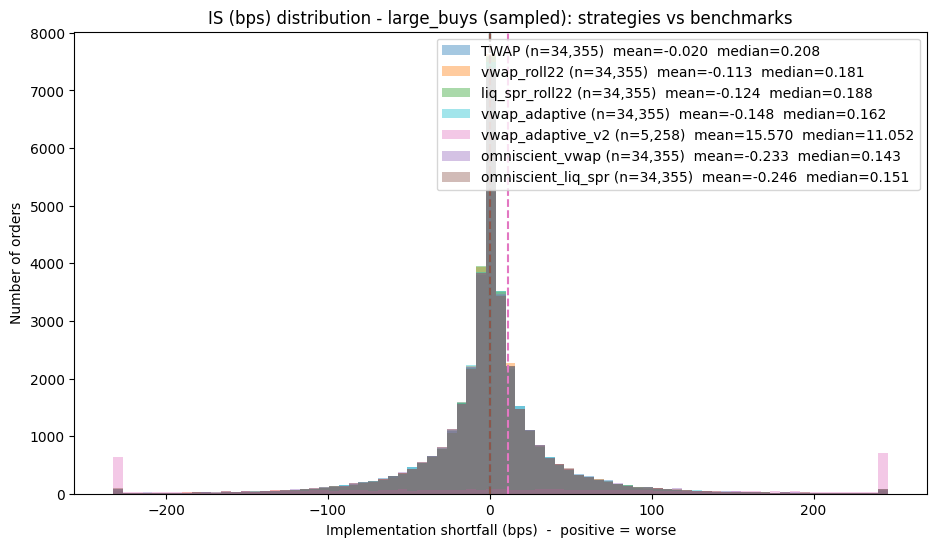

In [130]:
import numpy as np
import matplotlib.pyplot as plt

STRATS = [
    ("TWAP",               twap_summary_full,     "#1f77b4"),
    ("vwap_roll22",        vwap_summary_full,      "#ff7f0e"),
    ("liq_spr_roll22",     liqspr_summary_full,    "#2ca02c"),
    ("vwap_adaptive",      adaptive_summary_full,  "#17becf"),
    ("vwap_adaptive_v2",   adaptive_v2_summary_full, "#e377c2"),
    ("omniscient_vwap",    omnivwap_summary_full,  "#9467bd"),
    ("omniscient_liq_spr", omnilqs_summary_full,   "#8c564b"),
    # ("omniscient",       omni_summary_full,      "#d62728"),  # full lookahead incl. DRIFT — uncomment after running its cell
]
series = {name: s["is_bps"].drop_nulls().drop_nans().to_numpy() for name, s, _ in STRATS}

lo, hi = np.percentile(np.concatenate(list(series.values())), [0.5, 99.5])
edges = np.linspace(lo, hi, 80)

fig, ax = plt.subplots(figsize=(11, 6))
for name, _, color in STRATS:
    a = series[name]
    ax.hist(np.clip(a, lo, hi), bins=edges, alpha=0.40, color=color,
            label=f"{name} (n={len(a):,})  mean={a.mean():.3f}  median={np.median(a):.3f}")
    ax.axvline(np.median(a), color=color, ls="--", lw=1.5)
ax.set_xlabel("Implementation shortfall (bps)  -  positive = worse")
ax.set_ylabel("Number of orders")
ax.set_title(f"IS (bps) distribution - {BUCKET} (sampled): strategies vs benchmarks")
ax.legend()
plt.show()

### IS (bps) distribution **by qcode**

Faceted one panel per `qcode`, each clipped to that qcode's own [1, 99] percentile range. Dashed lines mark each strategy's per-panel median.


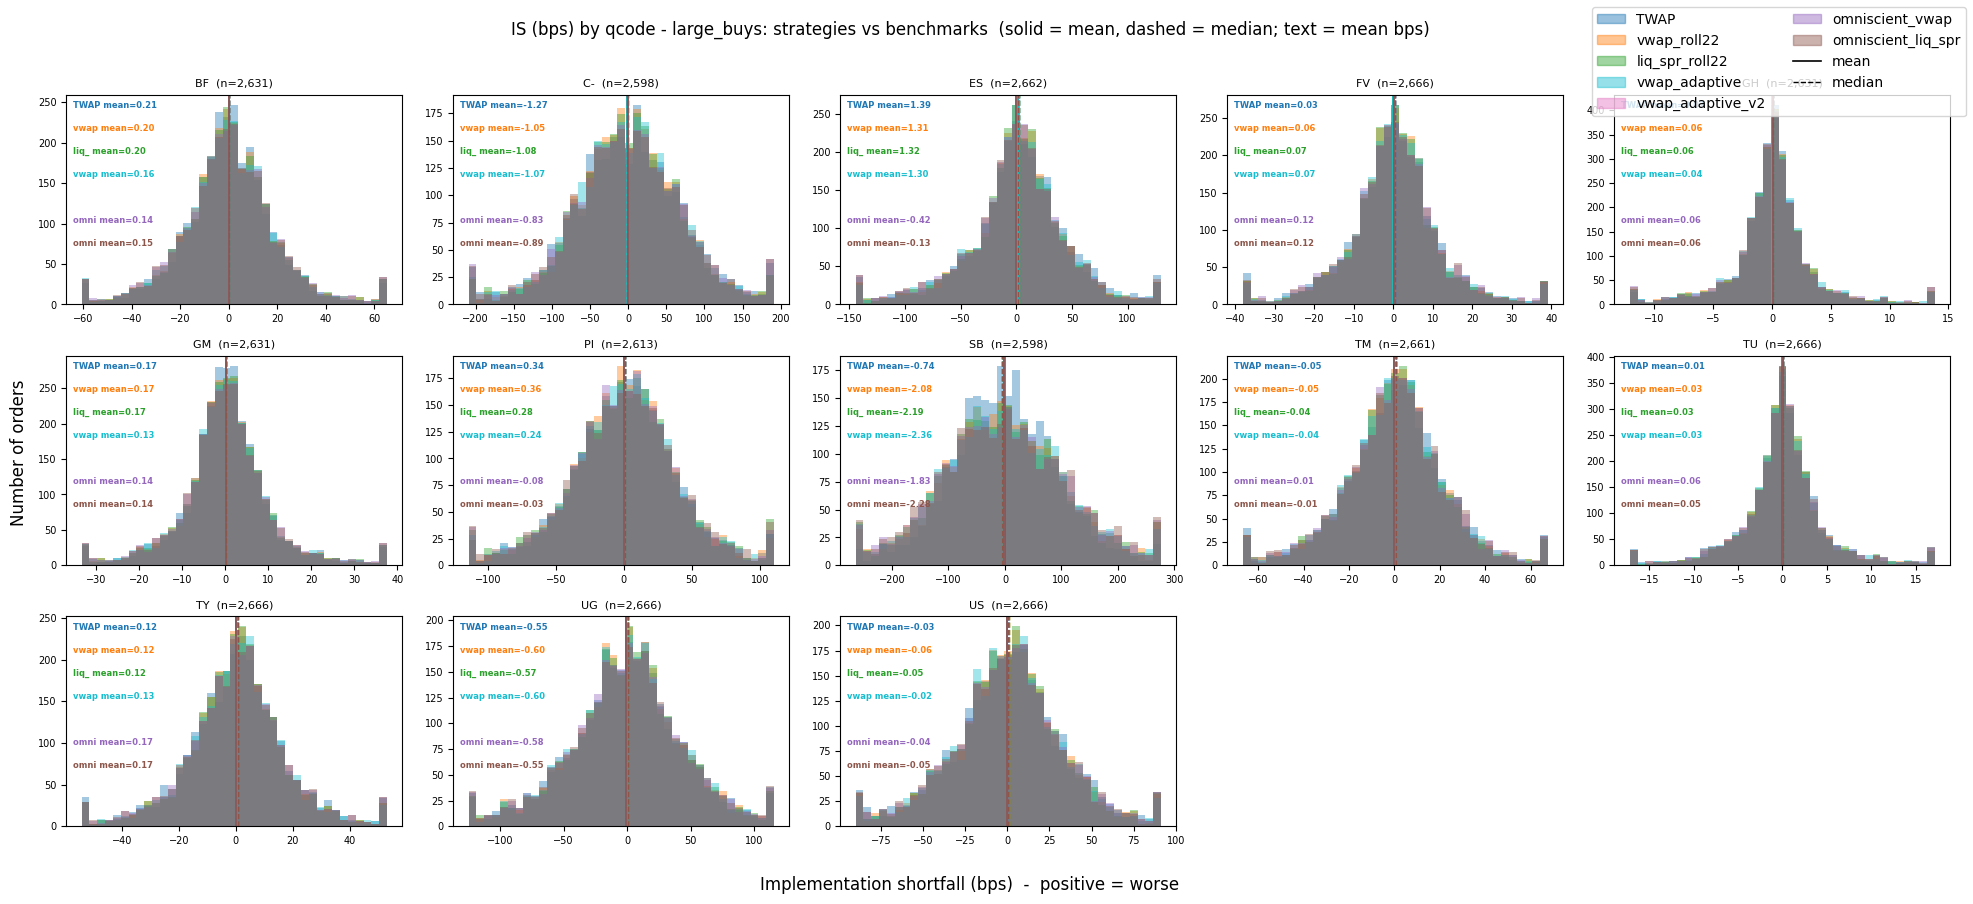

In [131]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

qcodes = sorted(set(twap_summary_full["qcode"].drop_nulls().to_list()))
ncols = 5
nrows = int(np.ceil(len(qcodes) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.0, nrows * 3.0))
axes = np.array(axes).reshape(-1)

def _isvals(df, q):
    return df.filter(pl.col("qcode") == q)["is_bps"].drop_nulls().drop_nans().to_numpy()

for ax, q in zip(axes, qcodes):
    arrs = [(name, _isvals(s, q), color) for name, s, color in STRATS]
    present = [a for _, a, _ in arrs if len(a)]
    both = np.concatenate(present) if present else np.array([0.0])
    lo, hi = np.percentile(both, [1, 99]) if both.size > 1 else (-1, 1)
    if lo == hi:
        lo, hi = lo - 1, hi + 1
    edges = np.linspace(lo, hi, 40)
    for j, (name, a, color) in enumerate(arrs):
        if len(a):
            ax.hist(np.clip(a, lo, hi), bins=edges, alpha=0.4, color=color)
            ax.axvline(a.mean(),     color=color, ls="-",  lw=1.2)   # solid  = mean
            ax.axvline(np.median(a), color=color, ls="--", lw=1.0)   # dashed = median
            # display the mean value (bps) as colour-coded text, stacked top-left
            ax.text(0.02, 0.97 - j * 0.11, f"{name[:4]} mean={a.mean():.2f}",
                    transform=ax.transAxes, color=color, fontsize=6,
                    va="top", ha="left", fontweight="bold")
    ax.set_title(f"{q}  (n={len(arrs[0][1]):,})", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[len(qcodes):]:
    ax.set_visible(False)

handles = [Patch(color=c, alpha=0.45, label=n) for n, _, c in STRATS]
handles += [Line2D([0], [0], color="k", ls="-", lw=1.2, label="mean"),
            Line2D([0], [0], color="k", ls="--", lw=1.0, label="median")]
fig.legend(handles=handles, loc="upper right", fontsize=10, ncol=2)
fig.suptitle(f"IS (bps) by qcode - {BUCKET}: strategies vs benchmarks  (solid = mean, dashed = median; text = mean bps)", fontsize=12)
fig.supxlabel("Implementation shortfall (bps)  -  positive = worse")
fig.supylabel("Number of orders")
fig.tight_layout(rect=[0.01, 0.01, 1, 0.97])
plt.show()

### IS decomposition — mean / median / variance per component

For each strategy, break `is_bps` into its three additive pieces (**slippage**, **drift**, **opportunity**) plus the **total**, and report the mean, median and (sample) variance in bps across orders. `decompose_is_stats` builds one labelled block per strategy; we stack them.

In [132]:
pl.Config.set_tbl_rows(40)   # show all 28 rows (7 strategies x 4 components)

decomp_table = pl.concat([
    decompose_is_stats(twap_summary_full,    "TWAP"),
    decompose_is_stats(vwap_summary_full,     "vwap_roll22"),
    decompose_is_stats(liqspr_summary_full,   "liq_spr_roll22"),
    decompose_is_stats(adaptive_summary_full, "vwap_adaptive"),
    decompose_is_stats(adaptive_v2_summary_full, "vwap_adaptive_v2"),
    decompose_is_stats(omnivwap_summary_full, "omniscient_vwap"),
    decompose_is_stats(omnilqs_summary_full,  "omniscient_liq_spr"),
])
# wide view: one row per strategy, columns per component-stat
decomp_wide = decomp_table.pivot(values=["mean", "median", "variance"],
                                 index="strategy", on="component")
decomp_table

strategy,component,mean,median,variance
str,str,f64,f64,f64
"""TWAP""","""slippage""",0.474821,0.271026,0.306892
"""TWAP""","""drift""",-0.486372,0.027797,1786.566554
"""TWAP""","""opportunity""",-0.008356,-0.0,26.000964
"""TWAP""","""total""",-0.019907,0.207988,1909.489272
"""vwap_roll22""","""slippage""",0.459036,0.264918,0.284687
"""vwap_roll22""","""drift""",-0.573969,0.012386,1940.68916
"""vwap_roll22""","""opportunity""",0.001755,-0.0,14.547366
"""vwap_roll22""","""total""",-0.113177,0.181032,2012.365068
"""liq_spr_roll22""","""slippage""",0.458883,0.264829,0.284737


### IS decomposition — grouped bar charts

Grouped by component (slippage / drift / opportunity / total), with one bar per strategy. **Top:** the *mean* bps contribution; **bottom:** the *variance* on a **log** scale — drift's variance dwarfs the rest by ~1000×, so it gets its own (log) axis rather than error bars on the means.

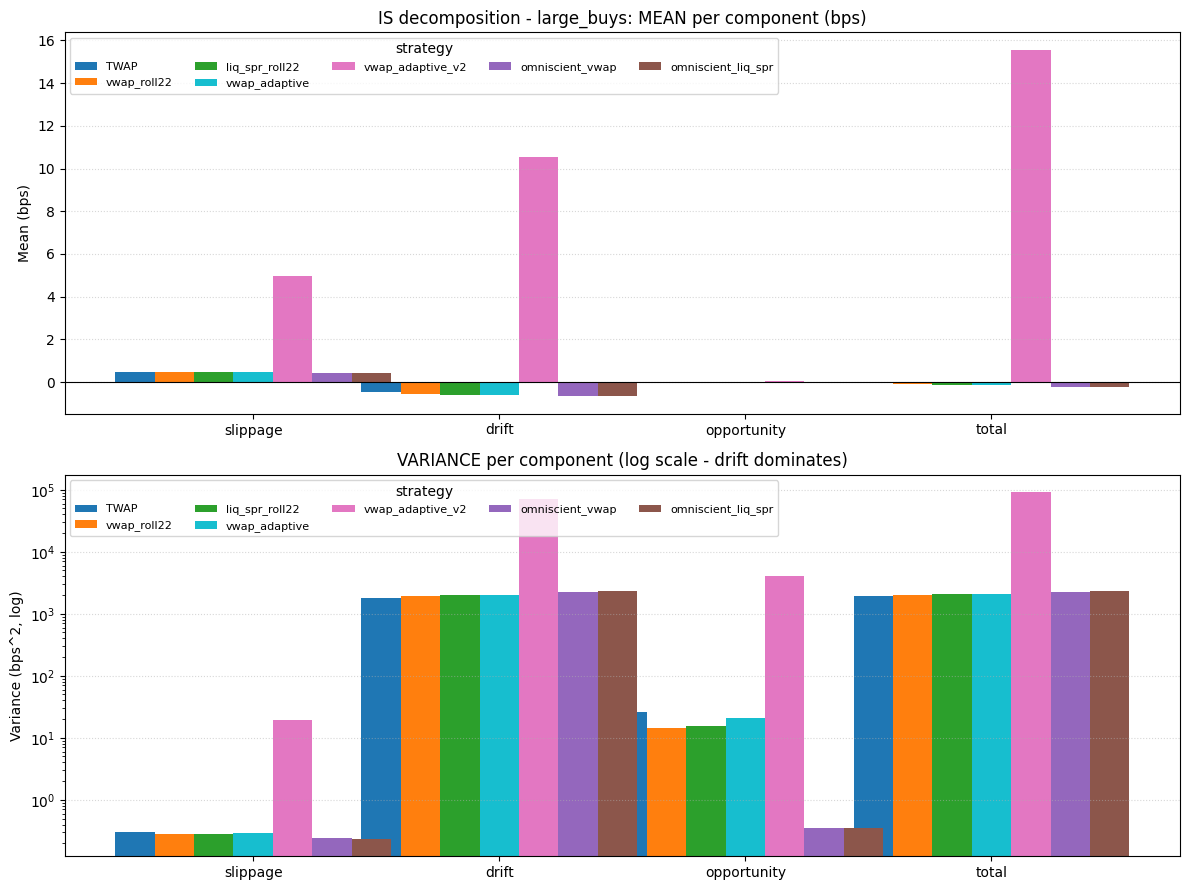

In [133]:
components = ["slippage", "drift", "opportunity", "total"]
strat_color = [(name, color) for name, _, color in STRATS]
strategies = [s for s, _ in strat_color]

def _val(stat, strat):
    return [decomp_table.filter((pl.col("strategy") == strat) & (pl.col("component") == comp))[stat][0]
            for comp in components]

x = np.arange(len(components)); n = len(strategies); w = 0.16
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

for j, (strat, color) in enumerate(strat_color):
    ax1.bar(x + (j - (n - 1) / 2) * w, _val("mean", strat), w, label=strat, color=color)
ax1.axhline(0, color="k", lw=0.8); ax1.set_ylabel("Mean (bps)")
ax1.set_title(f"IS decomposition - {BUCKET}: MEAN per component (bps)")
ax1.set_xticks(x); ax1.set_xticklabels(components)
ax1.legend(title="strategy", ncol=5, fontsize=8); ax1.grid(axis="y", ls=":", alpha=0.5)

for j, (strat, color) in enumerate(strat_color):
    ax2.bar(x + (j - (n - 1) / 2) * w, _val("variance", strat), w, label=strat, color=color)
ax2.set_yscale("log"); ax2.set_ylabel("Variance (bps^2, log)")
ax2.set_title("VARIANCE per component (log scale - drift dominates)")
ax2.set_xticks(x); ax2.set_xticklabels(components)
ax2.legend(title="strategy", ncol=5, fontsize=8); ax2.grid(axis="y", ls=":", alpha=0.5)

fig.tight_layout(); plt.show()